# 🫀 Framingham Heart Study — 10-Year CHD Risk Prediction (Logistic Regression)

This notebook builds an end-to-end **binary classification** pipeline to predict a patient's 10-year risk of developing **Coronary Heart Disease (CHD)** using the classic Framingham Heart Study dataset.

**Workflow**
1. Exploratory Data Analysis (EDA)
2. Missing value analysis & targeted, feature-specific imputation strategies
3. Correlation analysis
4. Train/test split & feature scaling
5. Logistic Regression modeling (with class balancing)
6. Model evaluation (classification report, confusion matrix, ROC-AUC)

**Dataset:** the Framingham Heart Study dataset — a real-world cardiovascular health dataset from an ongoing longitudinal study in Framingham, Massachusetts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Load the Dataset

In [2]:
df = pd.read_csv("../../Data/framingham.csv")

## 🔍 2. Exploratory Data Analysis

A first pass over the data: shape, dtypes, and summary statistics.

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

### Checking for Missing Values

In [7]:
df["education"].unique()

array([ 4.,  2.,  1.,  3., nan])

## 🧹 3. Missing Data Imputation

Each feature has a different missingness pattern, so instead of a single blanket strategy (e.g. dropping all rows with `NaN`), missing values are handled **column-by-column** with the most appropriate approach for that variable.

### `education` — filled with the mode
The most frequent education category is used to fill missing values.

In [8]:
df["education"] = df["education"].fillna(df["education"].mode()[0])

In [9]:
df["cigsPerDay"]

0        0.0
1        0.0
2       20.0
3       30.0
4       23.0
        ... 
4233     1.0
4234    43.0
4235    20.0
4236    15.0
4237     0.0
Name: cigsPerDay, Length: 4238, dtype: float64

### `cigsPerDay` — filled with the mean
Cigarette count per day is imputed with the column mean.

In [10]:
missing_cig_person = df[(df["currentSmoker"] == 0) & (df["cigsPerDay"].isna())]
missing_cig_person.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [11]:
df["cigsPerDay"].describe()

count    4209.000000
mean        9.003089
std        11.920094
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max        70.000000
Name: cigsPerDay, dtype: float64

In [12]:
df["cigsPerDay"] = df["cigsPerDay"].fillna(df["cigsPerDay"].mean().astype(int))

In [13]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay           0
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [14]:
df["cigsPerDay"]

0        0.0
1        0.0
2       20.0
3       30.0
4       23.0
        ... 
4233     1.0
4234    43.0
4235    20.0
4236    15.0
4237     0.0
Name: cigsPerDay, Length: 4238, dtype: float64

In [15]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


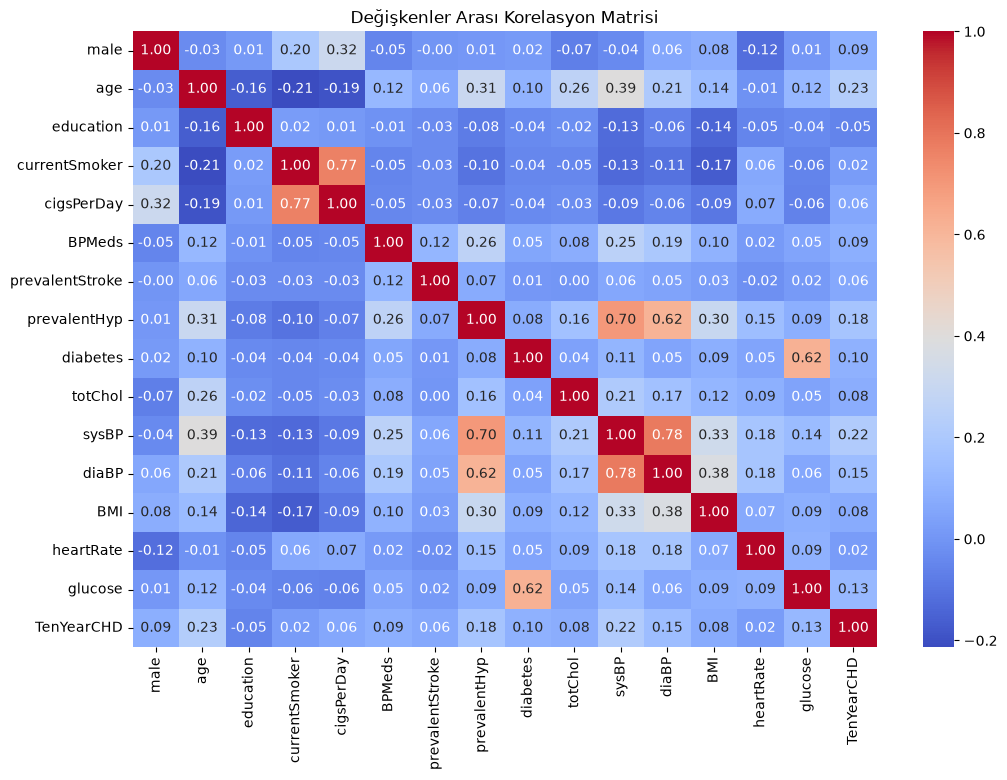

In [16]:
plt.figure(figsize=(12, 8))
# Sadece sayısal kolonların korelasyonunu alıp ısı haritasına döküyoruz
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

### Correlation Heatmap

Visualizing correlations helps identify which features are good predictors for imputing other missing columns — for example, which variables are most related to `BPMeds`.

BPMedsi en çok etkileyen faktörler diaBP, sysBP, prevalentHyp

In [17]:
nan_bpmeds = df[df["BPMeds"].isna()]

In [18]:
nan_bpmeds

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
49,1,36,3.0,1,20.0,NaN,0,1,0,194.0,139.0,93.0,24.33,80.0,62.0,0
77,0,44,3.0,1,20.0,NaN,0,0,0,213.0,115.0,72.5,21.16,80.0,89.0,0
193,1,45,3.0,1,40.0,NaN,0,0,0,278.0,135.0,84.0,23.79,75.0,79.0,1
245,1,46,1.0,1,30.0,NaN,0,1,0,253.0,147.0,85.0,30.62,100.0,75.0,0
314,0,39,2.0,0,0.0,NaN,0,0,0,242.0,113.0,85.0,25.54,85.0,104.0,0
395,0,65,2.0,0,0.0,NaN,0,1,0,270.0,165.0,98.0,21.66,62.0,92.0,1
421,1,44,1.0,0,0.0,NaN,0,0,1,190.0,122.0,81.0,36.12,70.0,143.0,0
765,1,50,4.0,1,9.0,NaN,0,0,0,296.0,119.0,90.0,23.55,75.0,69.0,1
769,0,37,3.0,0,0.0,NaN,0,0,0,145.0,105.0,73.0,23.44,58.0,80.0,0
797,0,59,4.0,0,0.0,NaN,0,1,0,240.0,195.0,118.0,23.82,80.0,73.0,0


In [19]:
nan_bpmeds = nan_bpmeds[["BPMeds","sysBP","diaBP","prevalentHyp"]]

In [20]:
nan_bpmeds

,BPMeds,sysBP,diaBP,prevalentHyp
49,NaN,139.0,93.0,1
77,NaN,115.0,72.5,0
193,NaN,135.0,84.0,0
245,NaN,147.0,85.0,1
314,NaN,113.0,85.0,0
395,NaN,165.0,98.0,1
421,NaN,122.0,81.0,0
765,NaN,119.0,90.0,0
769,NaN,105.0,73.0,0
797,NaN,195.0,118.0,1


In [21]:
df["sysBP"].describe()

count    4238.000000
mean      132.352407
std        22.038097
min        83.500000
25%       117.000000
50%       128.000000
75%       144.000000
max       295.000000
Name: sysBP, dtype: float64

In [22]:
df["diaBP"].describe()

count    4238.000000
mean       82.893464
std        11.910850
min        48.000000
25%        75.000000
50%        82.000000
75%        89.875000
max       142.500000
Name: diaBP, dtype: float64

In [23]:
import pandas as pd

def fill_bpmeds(row):
    if pd.isna(row["BPMeds"]):
        if row["prevalentHyp"] == 1:
            return 1.0
        elif row["sysBP"] >= 132:
            return 1.0
        elif row["diaBP"] >= 83:
            return 1.0
        else:
            return 0.0
    else:
        return row["BPMeds"]

df["BPMeds"] = df.apply(fill_bpmeds, axis=1)

### `BPMeds` — rule-based imputation

Blood pressure medication usage correlates strongly with hypertension and blood pressure readings. Missing `BPMeds` values are inferred with a simple rule: patients with prevalent hypertension, or elevated systolic/diastolic blood pressure, are assumed to be on medication.

In [24]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

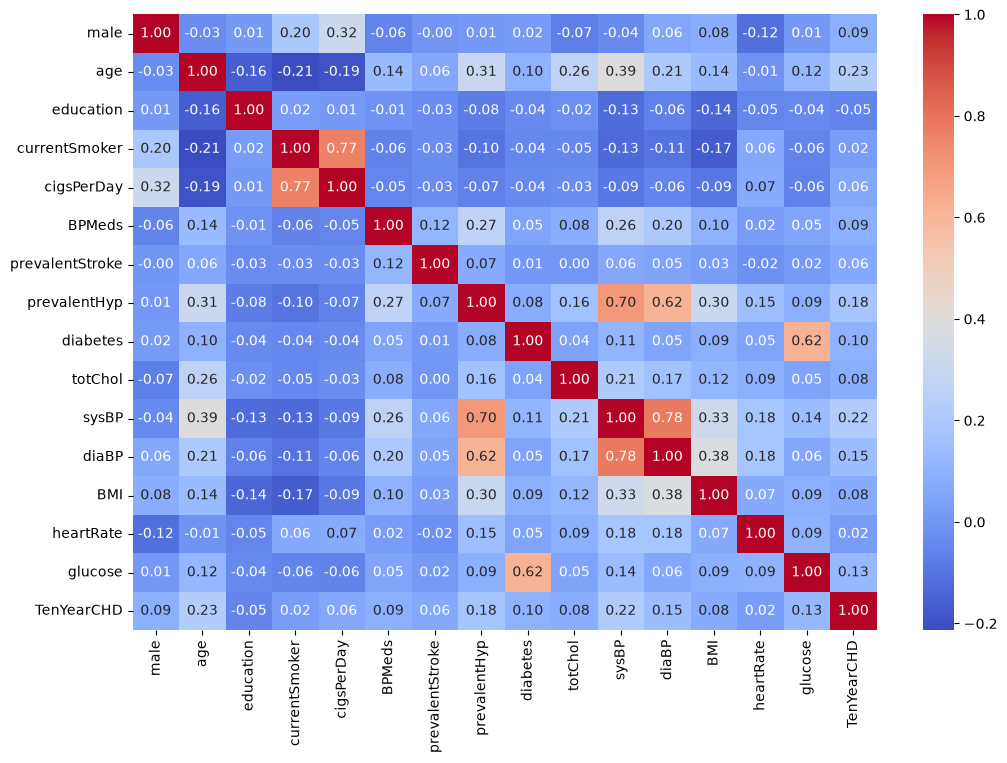

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [26]:
nan_totchol = df[df["totChol"].isna()]

### `totChol` — filled with the age-group mean

Cholesterol naturally varies with age, so missing values are imputed using the mean total cholesterol within each patient's age bracket rather than a single global mean.

In [27]:
nan_totchol

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
42,0,52,1.0,0,0.0,1.0,0,1,0,NaN,148.0,92.0,25.09,70.0,NaN,1
154,0,38,3.0,1,3.0,1.0,0,1,0,NaN,125.0,80.0,22.79,98.0,NaN,0
247,0,40,2.0,1,20.0,0.0,0,0,1,NaN,114.0,65.0,21.19,61.0,NaN,1
429,1,65,1.0,0,0.0,0.0,0,0,0,NaN,152.5,97.5,28.35,65.0,73.0,0
567,0,66,2.0,1,15.0,0.0,0,1,0,NaN,188.0,108.5,20.49,90.0,NaN,0
577,0,37,2.0,1,30.0,0.0,0,0,0,NaN,115.0,79.0,28.41,85.0,NaN,0
609,0,41,1.0,1,30.0,0.0,0,0,0,NaN,122.5,80.0,18.86,105.0,NaN,0
673,0,58,1.0,1,20.0,0.0,0,0,0,NaN,126.0,77.0,30.08,78.0,NaN,0
822,0,62,2.0,1,30.0,0.0,0,0,0,NaN,153.0,60.0,27.47,60.0,NaN,0
834,0,59,1.0,0,0.0,0.0,0,1,0,NaN,153.5,89.5,26.08,71.0,113.0,0


In [28]:
df["age"].describe()

count    4238.000000
mean       49.584946
std         8.572160
min        32.000000
25%        42.000000
50%        49.000000
75%        56.000000
max        70.000000
Name: age, dtype: float64

In [29]:
limits = [30, 40, 50, 60, 70]
labels = ['30-39', '40-49', '50-59', '60-70']

df['age_group'] = pd.cut(df['age'], bins=limits, labels=labels, right=False)

df['totChol'] = df['totChol'].fillna(df.groupby('age_group')['totChol'].transform('mean'))

df.drop('age_group', axis=1, inplace=True)

In [30]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol              0
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [31]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [32]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol              0
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

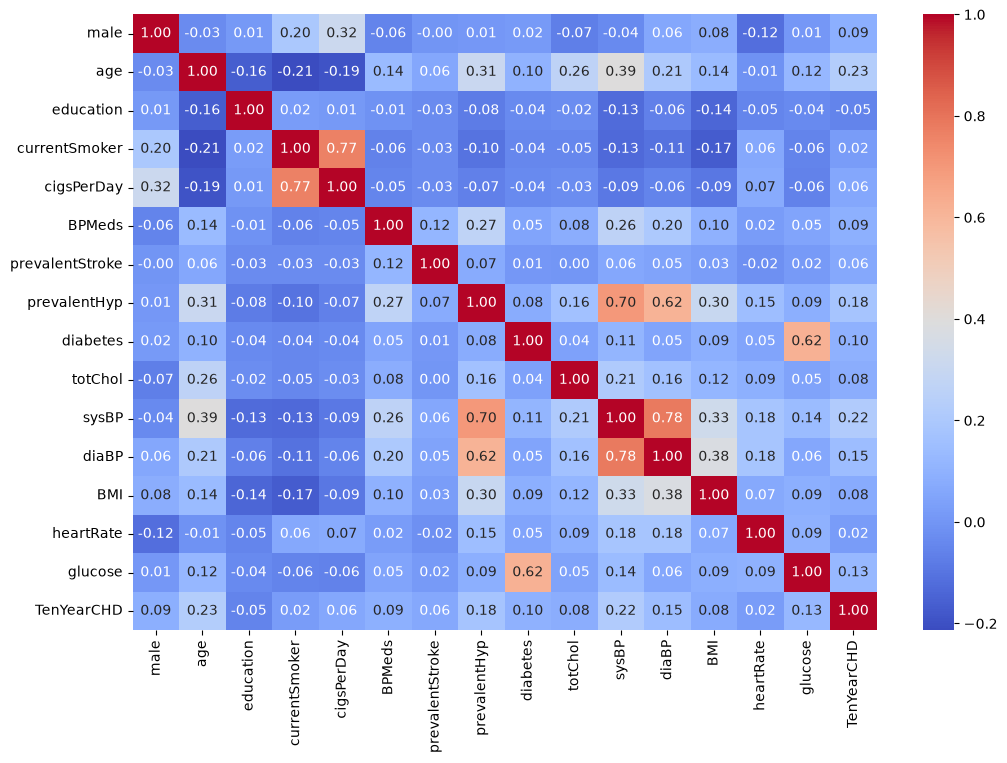

In [33]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [34]:
nan_glucose = df[df["glucose"].isna()]

### `glucose` — filled with the diabetes-group mean

Glucose levels differ substantially between diabetic and non-diabetic patients, so missing values are filled using the mean glucose level within each `diabetes` status group.

In [35]:
nan_glucose

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
14,0,39,2.0,1,9.0,0.0,0,0,0,226.000000,114.0,64.0,22.35,85.0,NaN,0
21,0,43,1.0,0,0.0,0.0,0,0,0,185.000000,123.5,77.5,29.89,70.0,NaN,0
26,0,60,1.0,0,0.0,0.0,0,0,0,260.000000,110.0,72.5,26.59,65.0,NaN,0
42,0,52,1.0,0,0.0,1.0,0,1,0,248.025076,148.0,92.0,25.09,70.0,NaN,1
54,0,39,2.0,1,20.0,0.0,0,0,0,209.000000,115.0,75.0,22.54,90.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170,0,41,2.0,1,5.0,0.0,0,0,0,205.000000,105.0,74.0,20.85,87.0,NaN,0
4208,0,51,1.0,1,9.0,0.0,0,0,0,340.000000,152.0,76.0,25.74,70.0,NaN,0
4229,0,51,3.0,1,20.0,0.0,0,1,0,251.000000,140.0,80.0,25.60,75.0,NaN,0
4230,0,56,1.0,1,3.0,0.0,0,1,0,268.000000,170.0,102.0,22.89,57.0,NaN,0


In [36]:
diabetes_df = df[df["diabetes"] == 1]

In [37]:
diabetes_df["glucose"].describe()

count    105.000000
mean     170.333333
std       84.232242
min       47.000000
25%      110.000000
50%      145.000000
75%      215.000000
max      394.000000
Name: glucose, dtype: float64

In [38]:
df["glucose"] = df["glucose"].fillna(df.groupby("diabetes")["glucose"].transform("mean"))

In [39]:
df.isnull().sum()

male                0
age                 0
education           0
currentSmoker       0
cigsPerDay          0
BPMeds              0
prevalentStroke     0
prevalentHyp        0
diabetes            0
totChol             0
sysBP               0
diaBP               0
BMI                19
heartRate           1
glucose             0
TenYearCHD          0
dtype: int64

In [40]:
nan_bmi = df[df["BMI"].isna()]
nan_bmi

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
97,0,40,2.0,0,0.0,0.0,0,0,0,205.000000,100.0,60.0,NaN,60.0,72.000000,1
294,0,47,1.0,1,25.0,0.0,0,1,1,258.000000,195.0,90.0,NaN,86.0,170.333333,1
705,0,45,3.0,0,0.0,0.0,0,0,0,231.000000,107.5,57.5,NaN,81.0,79.489186,0
1155,0,64,2.0,1,3.0,0.0,0,0,0,221.000000,148.0,85.0,NaN,90.0,80.000000,1
1161,0,47,2.0,0,0.0,0.0,0,0,0,195.000000,126.0,75.0,NaN,60.0,79.489186,1
1594,0,40,2.0,0,0.0,0.0,0,0,0,164.000000,135.0,75.0,NaN,75.0,85.000000,0
1604,1,40,1.0,1,20.0,0.0,0,0,0,266.000000,101.0,73.0,NaN,70.0,64.000000,0
1624,0,70,1.0,0,0.0,0.0,1,1,0,107.000000,143.0,93.0,NaN,68.0,62.000000,1
1747,0,51,1.0,0,0.0,0.0,0,0,0,248.025076,130.0,89.5,NaN,80.0,79.489186,0
1975,1,63,1.0,1,20.0,0.0,1,1,0,213.000000,163.0,94.0,NaN,76.0,69.000000,1


### `BMI` and `heartRate` — dropped

Only a handful of rows are missing these values, so instead of imputing (which risks introducing noise for so few cases), the affected rows are simply dropped.

In [41]:
df = df.dropna(subset=["BMI"])

In [42]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.000000,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.000000,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.000000,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.000000,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.000000,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.000000,0
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.000000,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,79.489186,0


In [43]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          1
glucose            0
TenYearCHD         0
dtype: int64

In [44]:
df = df.dropna(subset="heartRate")

In [45]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [46]:
X = df.drop(columns=["TenYearCHD"])
y = df["TenYearCHD"]

## 🎯 4. Feature / Target Split

With the dataset fully cleaned, the predictors (`X`) are separated from the target variable (`TenYearCHD`).

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 🤖 5. Model Building

### Train/Test Split
An 80/20 **stratified** split preserves the class balance of the target variable across both sets — important here since CHD cases are a minority class (~15% of patients).

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Feature Scaling

Logistic Regression is sensitive to feature magnitude, so all features are standardized (zero mean, unit variance) with `StandardScaler` — fit only on the training set to avoid data leakage into the test set.

In [49]:
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

### Fitting the Logistic Regression Model

`class_weight="balanced"` is used because only ~15% of patients in the dataset developed CHD within 10 years. Without this, the model would be biased toward predicting the majority (no-CHD) class.

In [ ]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gercek")
plt.show()

## 📊 6. Model Evaluation

### Classification Report & Confusion Matrix

Since the target is imbalanced, precision, recall, and F1-score are more informative than raw accuracy.

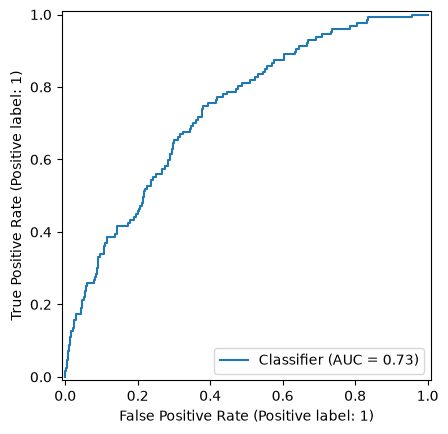

In [51]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

## ✅ Conclusion

This notebook walks through a complete, real-world classification workflow: feature-specific missing-data handling instead of a one-size-fits-all approach, correlation-driven imputation decisions, and a class-balanced Logistic Regression model evaluated with metrics suited to an imbalanced target (precision/recall/ROC-AUC rather than accuracy alone).

If you found this useful, an upvote is appreciated! 🙌

### ROC Curve

The ROC-AUC score summarizes the model's ability to distinguish between patients who will and won't develop CHD, independent of the classification threshold.